<a href="https://colab.research.google.com/github/priyal6/General-llm/blob/main/web_search_proto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -qU \
    langchain \
    langgraph \
    langchain-openai \
    langchain-tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 9.0 MB/s eta 0:00:00


In [ ]:
from google.colab import userdata

OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')

In [ ]:
from google.colab import userdata

TAVILY_API_KEY = userdata.get('TAVILY_API_KEY')

In [ ]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=4,
    topic="general",
    search_depth="basic",
    include_answer=False,
    include_raw_content=False,
    tavily_api_key=TAVILY_API_KEY
)

In [ ]:
search_result = tavily_search.invoke({
    "query": "What is continuos batching in LLM inference?"
})


search_result

{'query': 'What is continuos batching in LLM inference?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://machinelearningatscale.substack.com/p/llm-serving-1-continuous-batching',
   'title': 'LLM serving (1): Continuous batching - by Ludovico Bessi',
   'content': 'In summary, continuous batching is a crucial optimization technique for LLM inference servers that dynamically manages batches at the token generation level, allowing requests to enter and leave the batch independently, leading to much higher throughput and lower average latency compared to traditional static batching.\n\n# Technique 2: Paged attention\n\nThat’s coming in the next article :)\n\nSubscribe to not miss it!\n\n# References\n\nContinuous batching\n\n# \n\n#### Discussion about this post [...] Padding Waste: Shorter sequences often need to be padded to match the length of others in the batch during certain computations, wasting computation.\n\nContinuous Batching\n\nCon

In [ ]:
from langchain.agents import create_agent
from langchain_openai import ChatOpenAI

model = ChatOpenAI(
    model="gpt-5",
    temperature=0,
    api_key=OPENAI_API_KEY
)

agent = create_agent(
    model=model,
    tools=[tavily_search],
    system_prompt="""
    You are a web research assistant.

Use Tavily Search when the question requires:
- recent information;
- information you are uncertain about;
- external sources;
- technical documentation.

When using search:
1. Create a focused search query.
2. Read the search results carefully.
3. Answer using only supported information.
4. Include source URLs when available.
5. Clearly state when the evidence is insufficient.
    """
)

In [ ]:
result = agent.invoke({
    "messages": [
        {
            "role": "user",
            "content": (
                "explain how chunked prefill"
            ),
        }
    ]
})

In [ ]:
print(result["messages"][-1].content)

Here’s the idea in plain terms:

- What “prefill” is: During inference, the model first processes all input (prompt) tokens to build attention/key-value caches. That stage is compute-heavy and is called prefill. After that, it generates output tokens step by step (decode).
- What chunked prefill does: Instead of running one long prompt’s prefill in a single big block (which can block the GPU and delay others), the server splits the prefill into smaller chunks and interleaves those chunks with decode steps from other requests. This avoids head‑of‑line blocking and keeps the GPU busier, improving both latency and throughput. Sources: vLLM docs; NVIDIA TensorRT-LLM blog.
  - vLLM: “process large prefills in smaller chunks and batch them together with decode requests,” improving throughput and latency by better balancing compute-bound (prefill) and memory-bound (decode) work. The scheduler prioritizes decode; it fills a per-step token budget (max_num_batched_tokens), and if a pending prefi

LangGraph Version

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch

from langchain_core.messages import (
    BaseMessage,
    HumanMessage,
    SystemMessage,
)

from langgraph.graph import (
    StateGraph,
    START,
    END,
)

from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

In [ ]:
class AgentState(TypedDict):
  messages: Annotated[list[BaseMessage], add_messages]

In [ ]:
model = ChatOpenAI(
    model="gpt-5",
    temperature=0,
    api_key=OPENAI_API_KEY
)

search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="basic",
    tavily_api_key=TAVILY_API_KEY
)

tools = [search_tool]

model_with_tools = model.bind_tools(tools)

In [ ]:
SYSTEM_PROMPT = """
You are a web research assistant.

Search the web when the question requires external or current information.
Use focused search queries.
Base your final answer on the search results.
Include useful source URLs when available.
"""

def call_model(state: AgentState):
  response = model_with_tools.invoke(
      [
          SystemMessage(content=SYSTEM_PROMPT),
          *state["messages"],
      ]
  )

  return {
      "messages": [response]
  }

In [ ]:
tool_node = ToolNode(tools)

In [ ]:
def route_after_model(state: AgentState):
  last_message = state["messages"][-1]

  if last_message.tool_calls:
    return "tools"

  return END

In [ ]:
builder = StateGraph(AgentState)

builder.add_node("model", call_model)
builder.add_node("tools", tool_node)

builder.add_edge(START, "model")


builder.add_conditional_edges(
    "model",
    route_after_model,
    {
        "tools": "tools",
        END:END,
    },
)

builder.add_edge("tools", "model")

search_agent = builder.compile()

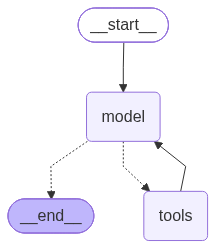

In [ ]:
from IPython.display import Image, display

display(
    Image(
        search_agent.get_graph().draw_mermaid_png()
    )
)

In [ ]:
result = search_agent.invoke({
    "messages": [
        HumanMessage(
            content=(
                "explain the difference between Ray Serve and llm-d for LLM inference."
            )
        )
    ]
})

print(result["messages"][-1].content)

Short answer: Ray Serve is a general-purpose, programmable serving layer inside the Ray ecosystem that can deploy LLM engines (like vLLM) with autoscaling, routing, and app composition. llm-d is a Kubernetes-native distributed inference stack that orchestrates many vLLM instances with advanced LLM-specific optimizations such as disaggregated prefill/decode and KV‑cache–aware routing across a cluster.

What Ray Serve focuses on
- General-purpose serving and app composition: Serve arbitrary Python, chains/pipelines, and multiple models with one toolkit; integrate business logic easily. Docs: https://docs.ray.io/en/latest/serve/index.html
- LLM-specific module (Ray Serve LLM): OpenAI-compatible API, tight vLLM integration, streaming, batching, multi-node/multi-GPU, multi-model, autoscaling, observability. Docs: https://docs.ray.io/en/latest/serve/llm/index.html
- vLLM compatibility: Use most vLLM engine arguments behind Ray Serve’s distributed deployment. Docs: https://docs.ray.io/en/late

In [ ]:
for message in result["messages"]:
  message.pretty_print()

================================ Human Message =================================

explain the difference between Ray Serve and llm-d for LLM inference.
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_EFkAEDDBIQzCYDil7mYNW6SZ)
 Call ID: call_EFkAEDDBIQzCYDil7mYNW6SZ
  Args:
    query: Ray Serve vs llm-d LLM inference what is llm-d
    search_depth: advanced
================================= Tool Message =================================
Name: tavily_search

{"query": "Ray Serve vs llm-d LLM inference what is llm-d", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://developers.redhat.com/articles/2025/11/21/introduction-distributed-inference-llm-d", "title": "Introduction to distributed inference with llm-d | Red Hat Developer", "content": "llm-d is an open source project dedicated to distributed LLM inference. It was created from the realization that traditional inference frameworks 